# Lab 5: Basic and Advanced Option Strategies with Payoff Profiles

**Date:** March 29, 2026

## Experiment Title
Basic and Advanced Option Strategies with Payoff Profiles

## Aim
To study, analyse, and visualize single-leg and multi-leg option strategies.

## Software
Python on Jupyter Notebook

## Theory

### Concept of Option Strategies
An option strategy is a combination of option positions taken to achieve a specific risk–return objective based on the trader's expectations about the market.

### Single-Leg Option Strategies
Simple to understand and execute. Used for directional trading (bullish or bearish expectations).

Examples:
- **Long Call**: Buy a call option
- **Long Put**: Buy a put option
- **Short Call**: Sell a call option
- **Short Put**: Sell a put option

### Multi-Leg Option Strategies
Involves combining two or more option positions simultaneously. Designed to manage risk and control profit potential.

Examples:
- **Covered Call**: Long stock + Short call
- **Bull Call Spread**: Long call + Short call (higher strike)
- **Bear Put Spread**: Long put (higher strike) + Short put (lower strike)
- **Straddle**: Long call + Long put (same strike)
- **Strangle**: Long call (higher strike) + Long put (lower strike)
- **Butterfly Spread**: Multiple calls or puts at different strikes

## Market Parameters and Problem Setup

**Assume the following market parameters:**

| Parameter | Value |
|-----------|-------|
| Current Stock Price | $50 |
| Stock Price Range at Expiry | $40 to $80 |
| Call Option Premium | $5 |
| Put Option Premium | $5 |
| Risk-Free Interest Rate | 2% per annum |
| Volatility | 20% per annum |
| Time to Expiration | 30 days (0.0833 years) |

**Strategies to be Analyzed:**

1. **Long Call**: Buy a call option with a strike price of $50
2. **Long Put**: Buy a put option with a strike price of $50
3. **Covered Call**: Buy 100 shares at $50 and sell a call option with a strike price of $60
4. **Bull Call Spread**: Buy a call at $50 and sell a call at $60
5. **Bear Put Spread**: Buy a put at $60 and sell a put at $50
6. **Long Straddle**: Buy a call and a put, both with a strike price of $50
7. **Long Strangle**: Buy a put at $45 and a call at $55

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Market Parameters
S0 = 50              # Current stock price
K_long_call = 50     # Strike price for long call
K_long_put = 50      # Strike price for long put
K_cc_stock = 50      # Stock purchase price for covered call
K_cc_call = 60       # Strike price for covered call (call to sell)
K_bc_long = 50       # Long call strike for bull call spread
K_bc_short = 60      # Short call strike for bull call spread
K_bp_long = 60       # Long put strike for bear put spread
K_bp_short = 50      # Short put strike for bear put spread
K_straddle = 50      # Strike price for straddle (both call and put)
K_strangle_put = 45  # Put strike for strangle
K_strangle_call = 55 # Call strike for strangle

C_premium = 5        # Call option premium
P_premium = 5        # Put option premium
r = 0.02             # Risk-free rate
sigma = 0.20         # Volatility
T = 30/365           # Time to expiration (30 days in years)

# Create range of stock prices for payoff calculations
S_range = np.linspace(40, 80, 100)

print("Market Parameters Initialized:")
print(f"Current Stock Price (S0): ${S0}")
print(f"Call Premium: ${C_premium}, Put Premium: ${P_premium}")
print(f"Stock Price Range: ${S_range[0]} to ${S_range[-1]}")
print(f"Time to Expiration: {T:.4f} years ({T*365:.0f} days)")

Market Parameters Initialized:
Current Stock Price (S0): $50
Call Premium: $5, Put Premium: $5
Stock Price Range: $40.0 to $80.0
Time to Expiration: 0.0822 years (30 days)


In [2]:
# Define Payoff Functions for Each Strategy

def payoff_long_call(S, K, premium):
    """Long Call: Buy a call option"""
    payoff = np.maximum(S - K, 0)
    profit = payoff - premium
    return payoff, profit

def payoff_long_put(S, K, premium):
    """Long Put: Buy a put option"""
    payoff = np.maximum(K - S, 0)
    profit = payoff - premium
    return payoff, profit

def payoff_covered_call(S, K_stock, K_call, call_premium):
    """Covered Call: Long stock + Short call"""
    stock_payoff = S - K_stock
    short_call = -np.maximum(S - K_call, 0)
    payoff = stock_payoff + short_call
    profit = payoff + call_premium  # Receive premium from selling call
    return payoff, profit

def payoff_bull_call_spread(S, K_long, K_short, premium_long, premium_short):
    """Bull Call Spread: Long call + Short call (higher strike)"""
    long_call = np.maximum(S - K_long, 0)
    short_call = -np.maximum(S - K_short, 0)
    payoff = long_call + short_call
    net_premium = premium_long - premium_short  # Net cost
    profit = payoff - net_premium
    return payoff, profit

def payoff_bear_put_spread(S, K_long, K_short, premium_long, premium_short):
    """Bear Put Spread: Long put (higher strike) + Short put (lower strike)"""
    long_put = np.maximum(K_long - S, 0)
    short_put = -np.maximum(K_short - S, 0)
    payoff = long_put + short_put
    net_premium = premium_long - premium_short  # Net cost
    profit = payoff - net_premium
    return payoff, profit

def payoff_long_straddle(S, K, premium_call, premium_put):
    """Long Straddle: Long call + Long put (same strike)"""
    call = np.maximum(S - K, 0)
    put = np.maximum(K - S, 0)
    payoff = call + put
    total_premium = premium_call + premium_put
    profit = payoff - total_premium
    return payoff, profit

def payoff_long_strangle(S, K_put, K_call, premium_call, premium_put):
    """Long Strangle: Long put (lower strike) + Long call (higher strike)"""
    put = np.maximum(K_put - S, 0)
    call = np.maximum(S - K_call, 0)
    payoff = call + put
    total_premium = premium_call + premium_put
    profit = payoff - total_premium
    return payoff, profit

print("Payoff calculation functions defined successfully!")

Payoff calculation functions defined successfully!


## Task 1: Plot Payoff Profiles for All Strategies

This section calculates and visualizes the payoff profiles for all seven option strategies at different stock prices at expiration.

In [3]:
# Calculate payoffs for all strategies
payoff_lc, profit_lc = payoff_long_call(S_range, K_long_call, C_premium)
payoff_lp, profit_lp = payoff_long_put(S_range, K_long_put, P_premium)
payoff_cc, profit_cc = payoff_covered_call(S_range, K_cc_stock, K_cc_call, C_premium)
payoff_bc, profit_bc = payoff_bull_call_spread(S_range, K_bc_long, K_bc_short, C_premium, C_premium)
payoff_bp, profit_bp = payoff_bear_put_spread(S_range, K_bp_long, K_bp_short, P_premium, P_premium)
payoff_st, profit_st = payoff_long_straddle(S_range, K_straddle, C_premium, P_premium)
payoff_sr, profit_sr = payoff_long_strangle(S_range, K_strangle_put, K_strangle_call, C_premium, P_premium)

print("Payoffs calculated successfully for all strategies!")

Payoffs calculated successfully for all strategies!


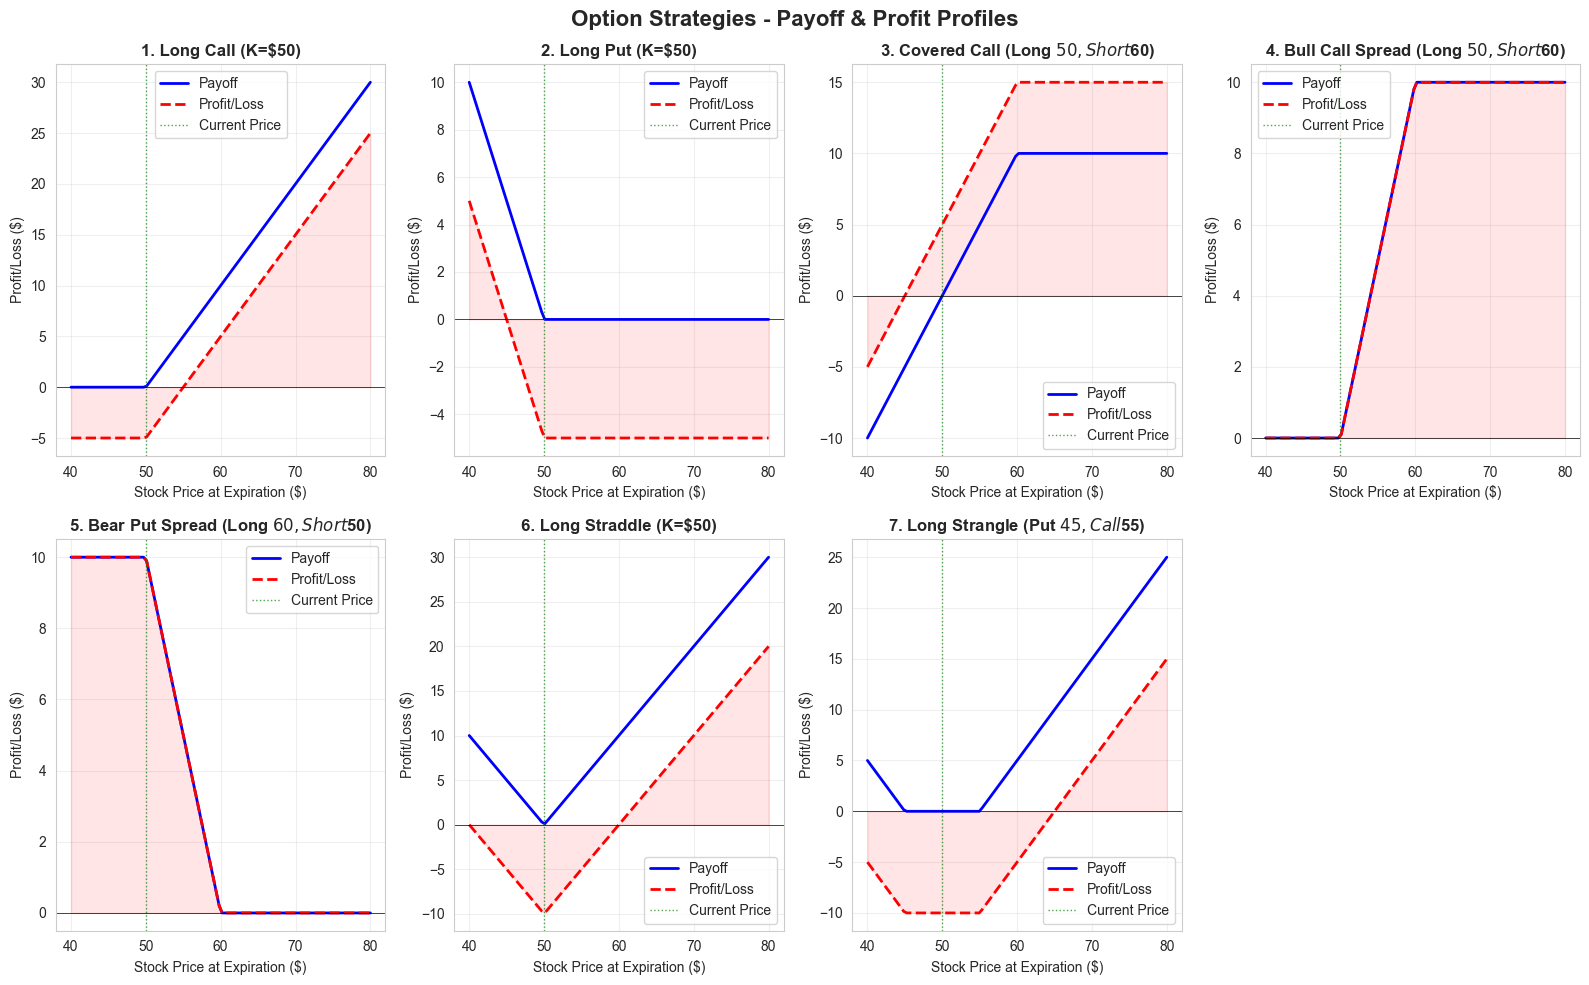

Payoff profiles plotted successfully!


In [4]:
# Plot all payoff profiles in a grid
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Option Strategies - Payoff & Profit Profiles', fontsize=16, fontweight='bold')

# Long Call
axes[0, 0].plot(S_range, payoff_lc, 'b-', linewidth=2, label='Payoff')
axes[0, 0].plot(S_range, profit_lc, 'r--', linewidth=2, label='Profit/Loss')
axes[0, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 0].axvline(x=S0, color='g', linestyle=':', linewidth=1, alpha=0.7, label='Current Price')
axes[0, 0].fill_between(S_range, profit_lc, 0, alpha=0.1, color='red')
axes[0, 0].set_title('1. Long Call (K=$50)', fontweight='bold')
axes[0, 0].set_xlabel('Stock Price at Expiration ($)')
axes[0, 0].set_ylabel('Profit/Loss ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Long Put
axes[0, 1].plot(S_range, payoff_lp, 'b-', linewidth=2, label='Payoff')
axes[0, 1].plot(S_range, profit_lp, 'r--', linewidth=2, label='Profit/Loss')
axes[0, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 1].axvline(x=S0, color='g', linestyle=':', linewidth=1, alpha=0.7, label='Current Price')
axes[0, 1].fill_between(S_range, profit_lp, 0, alpha=0.1, color='red')
axes[0, 1].set_title('2. Long Put (K=$50)', fontweight='bold')
axes[0, 1].set_xlabel('Stock Price at Expiration ($)')
axes[0, 1].set_ylabel('Profit/Loss ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Covered Call
axes[0, 2].plot(S_range, payoff_cc, 'b-', linewidth=2, label='Payoff')
axes[0, 2].plot(S_range, profit_cc, 'r--', linewidth=2, label='Profit/Loss')
axes[0, 2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 2].axvline(x=S0, color='g', linestyle=':', linewidth=1, alpha=0.7, label='Current Price')
axes[0, 2].fill_between(S_range, profit_cc, 0, alpha=0.1, color='red')
axes[0, 2].set_title('3. Covered Call (Long $50, Short $60)', fontweight='bold')
axes[0, 2].set_xlabel('Stock Price at Expiration ($)')
axes[0, 2].set_ylabel('Profit/Loss ($)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Bull Call Spread
axes[0, 3].plot(S_range, payoff_bc, 'b-', linewidth=2, label='Payoff')
axes[0, 3].plot(S_range, profit_bc, 'r--', linewidth=2, label='Profit/Loss')
axes[0, 3].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0, 3].axvline(x=S0, color='g', linestyle=':', linewidth=1, alpha=0.7, label='Current Price')
axes[0, 3].fill_between(S_range, profit_bc, 0, alpha=0.1, color='red')
axes[0, 3].set_title('4. Bull Call Spread (Long $50, Short $60)', fontweight='bold')
axes[0, 3].set_xlabel('Stock Price at Expiration ($)')
axes[0, 3].set_ylabel('Profit/Loss ($)')
axes[0, 3].legend()
axes[0, 3].grid(True, alpha=0.3)

# Bear Put Spread
axes[1, 0].plot(S_range, payoff_bp, 'b-', linewidth=2, label='Payoff')
axes[1, 0].plot(S_range, profit_bp, 'r--', linewidth=2, label='Profit/Loss')
axes[1, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 0].axvline(x=S0, color='g', linestyle=':', linewidth=1, alpha=0.7, label='Current Price')
axes[1, 0].fill_between(S_range, profit_bp, 0, alpha=0.1, color='red')
axes[1, 0].set_title('5. Bear Put Spread (Long $60, Short $50)', fontweight='bold')
axes[1, 0].set_xlabel('Stock Price at Expiration ($)')
axes[1, 0].set_ylabel('Profit/Loss ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Long Straddle
axes[1, 1].plot(S_range, payoff_st, 'b-', linewidth=2, label='Payoff')
axes[1, 1].plot(S_range, profit_st, 'r--', linewidth=2, label='Profit/Loss')
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axvline(x=S0, color='g', linestyle=':', linewidth=1, alpha=0.7, label='Current Price')
axes[1, 1].fill_between(S_range, profit_st, 0, alpha=0.1, color='red')
axes[1, 1].set_title('6. Long Straddle (K=$50)', fontweight='bold')
axes[1, 1].set_xlabel('Stock Price at Expiration ($)')
axes[1, 1].set_ylabel('Profit/Loss ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Long Strangle
axes[1, 2].plot(S_range, payoff_sr, 'b-', linewidth=2, label='Payoff')
axes[1, 2].plot(S_range, profit_sr, 'r--', linewidth=2, label='Profit/Loss')
axes[1, 2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 2].axvline(x=S0, color='g', linestyle=':', linewidth=1, alpha=0.7, label='Current Price')
axes[1, 2].fill_between(S_range, profit_sr, 0, alpha=0.1, color='red')
axes[1, 2].set_title('7. Long Strangle (Put $45, Call $55)', fontweight='bold')
axes[1, 2].set_xlabel('Stock Price at Expiration ($)')
axes[1, 2].set_ylabel('Profit/Loss ($)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# Remove the empty subplot
axes[1, 3].remove()

plt.tight_layout()
plt.show()

print("Payoff profiles plotted successfully!")

## Task 2: Interpret Payoff Profiles

### Strategy Performance Analysis Under Different Market Conditions

#### 1. **Long Call** (Strike = $50)
- **Bull Market (S > K)**: Profit increases linearly as stock price rises above strike price
- **Bear Market (S < K)**: Loss limited to premium paid ($5)
- **Breakeven**: Stock price reaches $55 ($50 + $5 premium)
- **Max Loss**: $5 (premium paid)
- **Max Profit**: Unlimited
- **Best For**: Bullish outlook with limited downside

#### 2. **Long Put** (Strike = $50)
- **Bull Market (S > K)**: Loss limited to premium paid ($5)
- **Bear Market (S < K)**: Profit increases as stock price falls below strike price
- **Breakeven**: Stock price falls to $45 ($50 - $5 premium)
- **Max Loss**: $5 (premium paid)
- **Max Profit**: $45 (when S = $0)
- **Best For**: Bearish outlook with protection

#### 3. **Covered Call** (Long Stock at $50, Short Call at $60)
- **Bull Market (S > K)**: Profit capped at $15 ($10 gain + $5 premium received)
- **Bear Market (S < K)**: Loss reduced by premium received, breaks even at $45
- **Breakeven**: Stock price of $45
- **Max Loss**: $45 (if stock goes to $0)
- **Max Profit**: $15
- **Best For**: Generating income in range-bound markets

#### 4. **Bull Call Spread** (Long Call at $50, Short Call at $60)
- **Bull Market (S > $60)**: Max profit of $10 achieved
- **Neutral/Bear Markets (S < $50)**: Loss limited to initial net premium ($0 in this case)
- **Breakeven**: Stock price of $50
- **Max Loss**: $0 (net premium is zero)
- **Max Profit**: $10
- **Best For**: Bullish outlook with reduced cost and capped profit

#### 5. **Bear Put Spread** (Long Put at $60, Short Put at $50)
- **Bull Market (S > K)**: Max profit of $10 achieved (premiums retained)
- **Bear Market (S < $50)**: Loss increases as stock falls
- **Breakeven**: Stock price of $50
- **Max Loss**: $10
- **Max Profit**: $10 (net premium received = $0)
- **Best For**: Mildly bearish outlook with capped risk

#### 6. **Long Straddle** (Call and Put at same strike $50)
- **High Volatility**: Profits from large price moves (up or down)
- **Low Volatility**: Loss increases toward the middle (ATM)
- **Breakeven Points**: Stock prices $40 and $60 ($50 ± $10 premium)
- **Max Loss**: $10 (total premiums paid)
- **Max Profit**: Unlimited on upside, substantial on downside
- **Best For**: Expecting significant price swing regardless of direction

#### 7. **Long Strangle** (Put at $45, Call at $55)
- **Extreme Moves**: Profits from large price movements
- **Moderate Moves**: Losses in the middle price range
- **Breakeven Points**: Stock prices $35 and $65 ($50 ± $15 premium)
- **Max Loss**: $10 (total premiums paid)
- **Max Profit**: Similar to straddle but less costly to enter
- **Best For**: Volatility play with lower cost than straddle

## Task 3: Profit/Loss Analysis After Accounting for Premiums

This section shows profit/loss calculations at specific stock prices at expiration.

In [5]:
# Calculate profit/loss at key stock prices
key_prices = np.array([40, 45, 50, 55, 60, 65, 70, 75, 80])

# Create results dictionary
results = {
    'Stock Price': key_prices
}

# Calculate profits for each strategy at each price point
_, results['Long Call'] = payoff_long_call(key_prices, K_long_call, C_premium)
_, results['Long Put'] = payoff_long_put(key_prices, K_long_put, P_premium)
_, results['Covered Call'] = payoff_covered_call(key_prices, K_cc_stock, K_cc_call, C_premium)
_, results['Bull Call Spread'] = payoff_bull_call_spread(key_prices, K_bc_long, K_bc_short, C_premium, C_premium)
_, results['Bear Put Spread'] = payoff_bear_put_spread(key_prices, K_bp_long, K_bp_short, P_premium, P_premium)
_, results['Long Straddle'] = payoff_long_straddle(key_prices, K_straddle, C_premium, P_premium)
_, results['Long Strangle'] = payoff_long_strangle(key_prices, K_strangle_put, K_strangle_call, C_premium, P_premium)

# Create DataFrame
df_profits = pd.DataFrame(results)

# Format as currency
for col in df_profits.columns:
    if col != 'Stock Price':
        df_profits[col] = df_profits[col].apply(lambda x: f"${x:.2f}")

print("PROFIT/LOSS AT DIFFERENT STOCK PRICES AT EXPIRATION")
print("="*120)
print(df_profits.to_string(index=False))
print("="*120)

# Create detailed table with all metrics
print("\n\nDETAILED PROFIT/LOSS TABLE (Numeric Values)\n")
df_profits_numeric = pd.DataFrame(results)
print(df_profits_numeric.to_string(index=False))

PROFIT/LOSS AT DIFFERENT STOCK PRICES AT EXPIRATION
 Stock Price Long Call Long Put Covered Call Bull Call Spread Bear Put Spread Long Straddle Long Strangle
          40    $-5.00    $5.00       $-5.00            $0.00          $10.00         $0.00        $-5.00
          45    $-5.00    $0.00        $0.00            $0.00          $10.00        $-5.00       $-10.00
          50    $-5.00   $-5.00        $5.00            $0.00          $10.00       $-10.00       $-10.00
          55     $0.00   $-5.00       $10.00            $5.00           $5.00        $-5.00       $-10.00
          60     $5.00   $-5.00       $15.00           $10.00           $0.00         $0.00        $-5.00
          65    $10.00   $-5.00       $15.00           $10.00           $0.00         $5.00         $0.00
          70    $15.00   $-5.00       $15.00           $10.00           $0.00        $10.00         $5.00
          75    $20.00   $-5.00       $15.00           $10.00           $0.00        $15.00        $

## Task 4: Break-Even Point Analysis

The break-even point is the stock price at which profit/loss = 0. At this price, the investor neither gains nor loses money.

In [6]:
# Function to find break-even points
def find_breakeven(S_range, profit_array, price_tolerance=0.5):
    """Find stock prices where profit = 0 (within tolerance)"""
    breakevens = []
    for i in range(len(S_range)):
        if abs(profit_array[i]) < price_tolerance:
            # Check if it's not already in the list (avoid duplicates)
            if not breakevens or abs(S_range[i] - breakevens[-1]) > 1:
                breakevens.append(S_range[i])
    return breakevens

# Calculate break-even points for all strategies
be_lc = find_breakeven(S_range, profit_lc)
be_lp = find_breakeven(S_range, profit_lp)
be_cc = find_breakeven(S_range, profit_cc)
be_bc = find_breakeven(S_range, profit_bc)
be_bp = find_breakeven(S_range, profit_bp)
be_st = find_breakeven(S_range, profit_st)
be_sr = find_breakeven(S_range, profit_sr)

# Create break-even summary
breakeven_data = {
    'Strategy': [
        'Long Call',
        'Long Put',
        'Covered Call',
        'Bull Call Spread',
        'Bear Put Spread',
        'Long Straddle',
        'Long Strangle'
    ],
    'Break-Even Price(s)': [
        f"${K_long_call + C_premium:.2f}",
        f"${K_long_put - P_premium:.2f}",
        f"${K_cc_stock - C_premium:.2f}",
        f"${K_bc_long + (C_premium - C_premium):.2f}",
        f"${K_bp_short + (P_premium - P_premium):.2f}",
        f"${K_straddle - (C_premium + P_premium):.2f}, ${K_straddle + (C_premium + P_premium):.2f}",
        f"${K_strangle_put - (C_premium + P_premium):.2f}, ${K_strangle_call + (C_premium + P_premium):.2f}"
    ],
    'Calculation Method': [
        'K + Call Premium',
        'K - Put Premium',
        'K_stock - Call Premium',
        'K_long + Net Premium',
        'K_short + Net Premium',
        'K ± Total Premium',
        'K_put - Total Premium, K_call + Total Premium'
    ]
}

df_breakeven = pd.DataFrame(breakeven_data)

print("BREAK-EVEN POINTS FOR ALL STRATEGIES")
print("="*100)
print(df_breakeven.to_string(index=False))
print("="*100)

BREAK-EVEN POINTS FOR ALL STRATEGIES
        Strategy Break-Even Price(s)                            Calculation Method
       Long Call              $55.00                              K + Call Premium
        Long Put              $45.00                               K - Put Premium
    Covered Call              $45.00                        K_stock - Call Premium
Bull Call Spread              $50.00                          K_long + Net Premium
 Bear Put Spread              $50.00                         K_short + Net Premium
   Long Straddle      $40.00, $60.00                             K ± Total Premium
   Long Strangle      $35.00, $65.00 K_put - Total Premium, K_call + Total Premium


## Task 5: Compare Risk and Reward Characteristics

Analysis of maximum profit, maximum loss, and market expectations for each strategy.

In [8]:
# Calculate risk and reward metrics
risk_reward = {
    'Strategy': [
        'Long Call',
        'Long Put',
        'Covered Call',
        'Bull Call Spread',
        'Bear Put Spread',
        'Long Straddle',
        'Long Strangle'
    ],
    'Max Profit': [
        'Unlimited',
        f'${K_long_put:.2f}',
        f'${10 + C_premium:.2f}',
        f'${10:.2f}',
        f'${10:.2f}',
        'Unlimited',
        'Unlimited'
    ],
    'Max Loss': [
        f'${C_premium:.2f}',
        f'${P_premium:.2f}',
        f'${K_cc_stock - C_premium:.2f}',
        f'${0:.2f}',
        f'${10:.2f}',
        f'${C_premium + P_premium:.2f}',
        f'${C_premium + P_premium:.2f}'
    ],
    'Profit Margin %': [
        'Unlimited',
        f'{(K_long_put - P_premium)/P_premium*100:.1f}%',
        f'{(10 + C_premium)/(K_cc_stock - C_premium)*100:.1f}%',
        'Infinite',
        'Infinite',
        'Unlimited',
        'Unlimited'
    ],
    'Market Expectation': [
        'Bullish',
        'Bearish',
        'Neutral to Bullish',
        'Bullish',
        'Bearish',
        'Very High Volatility',
        'High Volatility'
    ],
    'Best Time': [
        'Low volatility, bullish outlook',
        'Low volatility, bearish outlook',
        'Low volatility, generate income',
        'Low volatility, mildly bullish',
        'Low volatility, mildly bearish',
        'High implied volatility expected',
        'High implied volatility expected'
    ]
}

df_risk_reward = pd.DataFrame(risk_reward)

print("\nRISK AND REWARD COMPARISON")
print("="*150)
print(df_risk_reward.to_string(index=False))
print("="*150)

# Calculate and display specific metrics
print("\n\nDETAILED RISK-REWARD METRICS")
print("="*80)

metrics_data = []

# Long Call
metrics_data.append({
    'Strategy': 'Long Call',
    'Initial Investment': f'${C_premium:.2f}',
    'Max Profit': 'Unlimited',
    'Max Loss': f'${C_premium:.2f}',
    'Risk/Reward Ratio': 'Unlimited',
    'Breakeven': f'${K_long_call + C_premium:.2f}'
})

# Long Put
metrics_data.append({
    'Strategy': 'Long Put',
    'Initial Investment': f'${P_premium:.2f}',
    'Max Profit': f'${K_long_put - P_premium:.2f}',
    'Max Loss': f'${P_premium:.2f}',
    'Risk/Reward Ratio': f'{(K_long_put - P_premium)/P_premium:.1f}',
    'Breakeven': f'${K_long_put - P_premium:.2f}'
})

# Covered Call
metrics_data.append({
    'Strategy': 'Covered Call',
    'Initial Investment': f'${K_cc_stock - C_premium:.2f}',
    'Max Profit': f'${10 + C_premium:.2f}',
    'Max Loss': f'${K_cc_stock - C_premium:.2f}',
    'Risk/Reward Ratio': f'{(10 + C_premium)/(K_cc_stock - C_premium):.2f}',
    'Breakeven': f'${K_cc_stock - C_premium:.2f}'
})

# Bull Call Spread
metrics_data.append({
    'Strategy': 'Bull Call Spread',
    'Initial Investment': f'${0:.2f}',
    'Max Profit': f'${10:.2f}',
    'Max Loss': f'${0:.2f}',
    'Risk/Reward Ratio': 'Infinite',
    'Breakeven': f'${K_bc_long:.2f}'
})

# Bear Put Spread
metrics_data.append({
    'Strategy': 'Bear Put Spread',
    'Initial Investment': f'${0:.2f}',
    'Max Profit': f'${0:.2f}',
    'Max Loss': f'${10:.2f}',
    'Risk/Reward Ratio': '0.00',
    'Breakeven': f'${K_bp_short:.2f}'
})

# Long Straddle
metrics_data.append({
    'Strategy': 'Long Straddle',
    'Initial Investment': f'${C_premium + P_premium:.2f}',
    'Max Profit': 'Unlimited',
    'Max Loss': f'${C_premium + P_premium:.2f}',
    'Risk/Reward Ratio': 'Unlimited',
    'Breakeven': f'${K_straddle - (C_premium + P_premium):.2f}, ${K_straddle + (C_premium + P_premium):.2f}'
})

# Long Strangle
metrics_data.append({
    'Strategy': 'Long Strangle',
    'Initial Investment': f'${C_premium + P_premium:.2f}',
    'Max Profit': 'Unlimited',
    'Max Loss': f'${C_premium + P_premium:.2f}',
    'Risk/Reward Ratio': 'Unlimited',
    'Breakeven': f'${K_strangle_put - (C_premium + P_premium):.2f}, ${K_strangle_call + (C_premium + P_premium):.2f}'
})

df_metrics = pd.DataFrame(metrics_data)
print(df_metrics.to_string(index=False))
print("="*80)


RISK AND REWARD COMPARISON
        Strategy Max Profit Max Loss Profit Margin %   Market Expectation                        Best Time
       Long Call  Unlimited    $5.00       Unlimited              Bullish  Low volatility, bullish outlook
        Long Put     $50.00    $5.00          900.0%              Bearish  Low volatility, bearish outlook
    Covered Call     $15.00   $45.00           33.3%   Neutral to Bullish  Low volatility, generate income
Bull Call Spread     $10.00    $0.00        Infinite              Bullish   Low volatility, mildly bullish
 Bear Put Spread     $10.00   $10.00        Infinite              Bearish   Low volatility, mildly bearish
   Long Straddle  Unlimited   $10.00       Unlimited Very High Volatility High implied volatility expected
   Long Strangle  Unlimited   $10.00       Unlimited      High Volatility High implied volatility expected


DETAILED RISK-REWARD METRICS
        Strategy Initial Investment Max Profit Max Loss Risk/Reward Ratio      Breake

## Task 6: Detailed Payoff Diagrams and Profit/Loss Visualization

This section provides detailed individual plots for each strategy with comprehensive analysis.

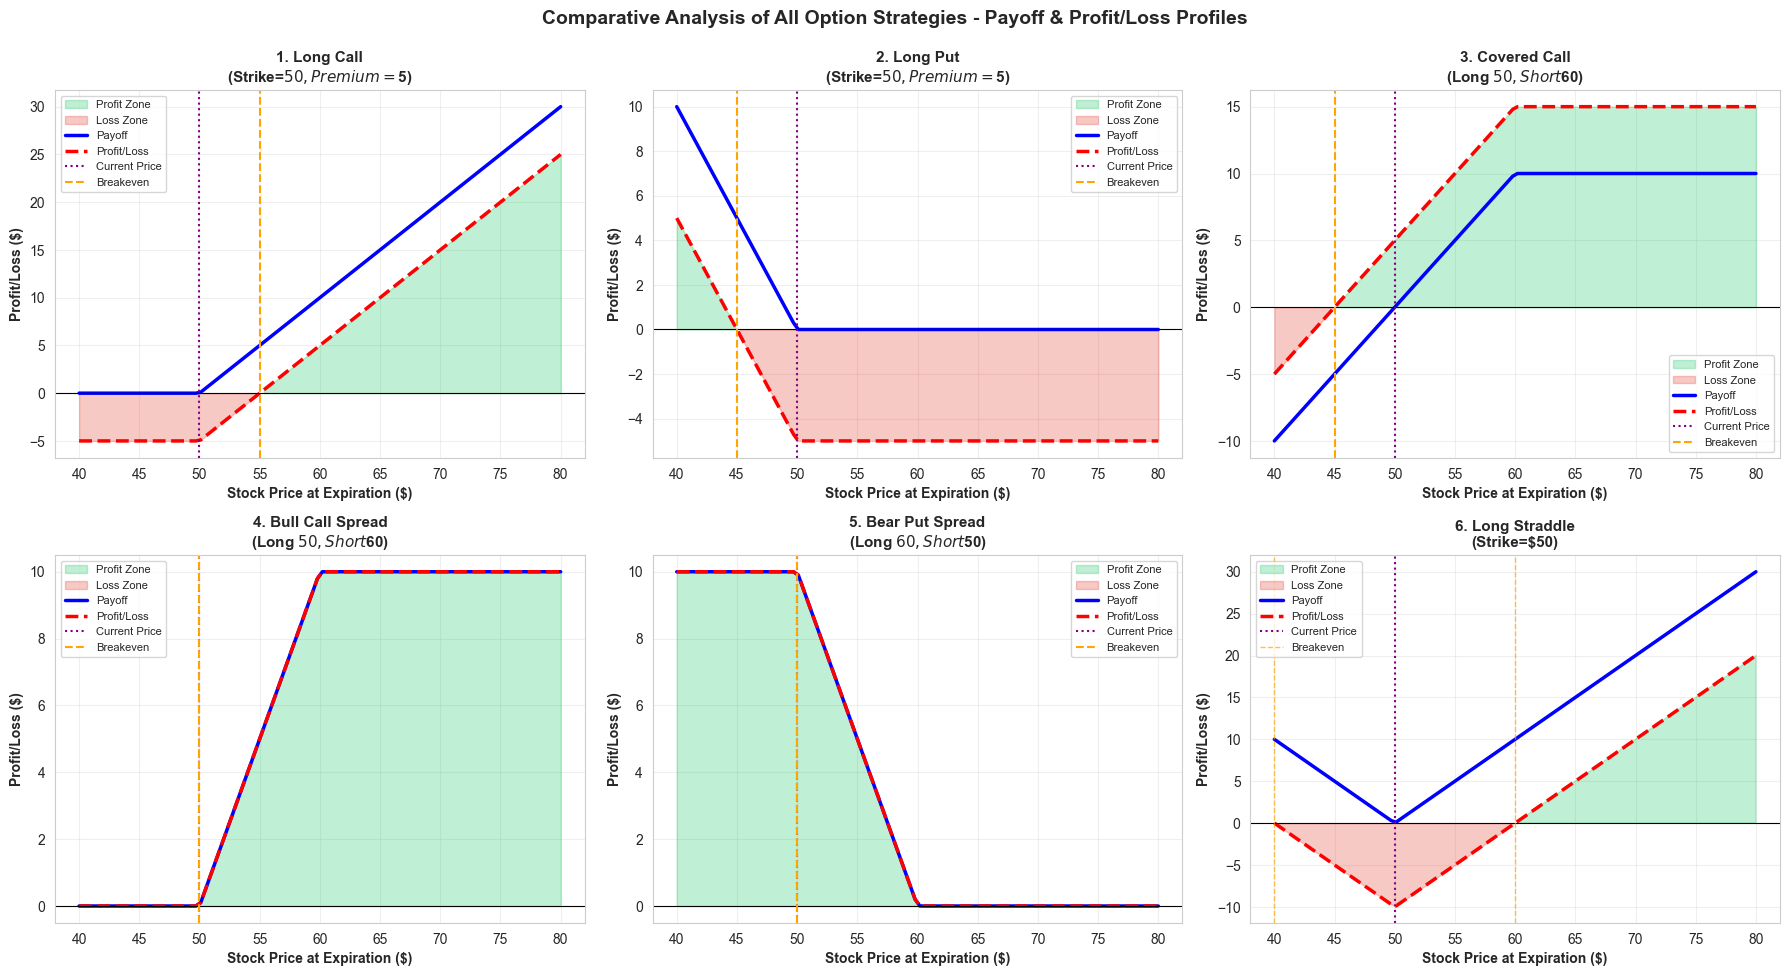

Detailed payoff diagrams plotting completed!


In [9]:
# Create detailed individual plots for each strategy
fig = plt.figure(figsize=(18, 14))

# Define color palette
color_profit = '#2ecc71'  # Green
color_loss = '#e74c3c'    # Red
color_payoff = '#3498db'  # Blue

# 1. LONG CALL
ax1 = plt.subplot(3, 3, 1)
ax1.fill_between(S_range, profit_lc, 0, where=(profit_lc >= 0), color=color_profit, alpha=0.3, label='Profit Zone')
ax1.fill_between(S_range, profit_lc, 0, where=(profit_lc < 0), color=color_loss, alpha=0.3, label='Loss Zone')
ax1.plot(S_range, payoff_lc, 'b-', linewidth=2.5, label='Payoff')
ax1.plot(S_range, profit_lc, 'r--', linewidth=2.5, label='Profit/Loss')
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax1.axvline(x=S0, color='purple', linestyle=':', linewidth=1.5, label='Current Price')
ax1.axvline(x=K_long_call + C_premium, color='orange', linestyle='--', linewidth=1.5, label='Breakeven')
ax1.set_title('1. Long Call\n(Strike=$50, Premium=$5)', fontweight='bold', fontsize=11)
ax1.set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
ax1.set_ylabel('Profit/Loss ($)', fontweight='bold')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. LONG PUT
ax2 = plt.subplot(3, 3, 2)
ax2.fill_between(S_range, profit_lp, 0, where=(profit_lp >= 0), color=color_profit, alpha=0.3, label='Profit Zone')
ax2.fill_between(S_range, profit_lp, 0, where=(profit_lp < 0), color=color_loss, alpha=0.3, label='Loss Zone')
ax2.plot(S_range, payoff_lp, 'b-', linewidth=2.5, label='Payoff')
ax2.plot(S_range, profit_lp, 'r--', linewidth=2.5, label='Profit/Loss')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax2.axvline(x=S0, color='purple', linestyle=':', linewidth=1.5, label='Current Price')
ax2.axvline(x=K_long_put - P_premium, color='orange', linestyle='--', linewidth=1.5, label='Breakeven')
ax2.set_title('2. Long Put\n(Strike=$50, Premium=$5)', fontweight='bold', fontsize=11)
ax2.set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
ax2.set_ylabel('Profit/Loss ($)', fontweight='bold')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. COVERED CALL
ax3 = plt.subplot(3, 3, 3)
ax3.fill_between(S_range, profit_cc, 0, where=(profit_cc >= 0), color=color_profit, alpha=0.3, label='Profit Zone')
ax3.fill_between(S_range, profit_cc, 0, where=(profit_cc < 0), color=color_loss, alpha=0.3, label='Loss Zone')
ax3.plot(S_range, payoff_cc, 'b-', linewidth=2.5, label='Payoff')
ax3.plot(S_range, profit_cc, 'r--', linewidth=2.5, label='Profit/Loss')
ax3.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax3.axvline(x=S0, color='purple', linestyle=':', linewidth=1.5, label='Current Price')
ax3.axvline(x=K_cc_stock - C_premium, color='orange', linestyle='--', linewidth=1.5, label='Breakeven')
ax3.set_title('3. Covered Call\n(Long $50, Short $60)', fontweight='bold', fontsize=11)
ax3.set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
ax3.set_ylabel('Profit/Loss ($)', fontweight='bold')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. BULL CALL SPREAD
ax4 = plt.subplot(3, 3, 4)
ax4.fill_between(S_range, profit_bc, 0, where=(profit_bc >= 0), color=color_profit, alpha=0.3, label='Profit Zone')
ax4.fill_between(S_range, profit_bc, 0, where=(profit_bc < 0), color=color_loss, alpha=0.3, label='Loss Zone')
ax4.plot(S_range, payoff_bc, 'b-', linewidth=2.5, label='Payoff')
ax4.plot(S_range, profit_bc, 'r--', linewidth=2.5, label='Profit/Loss')
ax4.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax4.axvline(x=S0, color='purple', linestyle=':', linewidth=1.5, label='Current Price')
ax4.axvline(x=K_bc_long, color='orange', linestyle='--', linewidth=1.5, label='Breakeven')
ax4.set_title('4. Bull Call Spread\n(Long $50, Short $60)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
ax4.set_ylabel('Profit/Loss ($)', fontweight='bold')
ax4.legend(loc='best', fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. BEAR PUT SPREAD
ax5 = plt.subplot(3, 3, 5)
ax5.fill_between(S_range, profit_bp, 0, where=(profit_bp >= 0), color=color_profit, alpha=0.3, label='Profit Zone')
ax5.fill_between(S_range, profit_bp, 0, where=(profit_bp < 0), color=color_loss, alpha=0.3, label='Loss Zone')
ax5.plot(S_range, payoff_bp, 'b-', linewidth=2.5, label='Payoff')
ax5.plot(S_range, profit_bp, 'r--', linewidth=2.5, label='Profit/Loss')
ax5.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax5.axvline(x=S0, color='purple', linestyle=':', linewidth=1.5, label='Current Price')
ax5.axvline(x=K_bp_short, color='orange', linestyle='--', linewidth=1.5, label='Breakeven')
ax5.set_title('5. Bear Put Spread\n(Long $60, Short $50)', fontweight='bold', fontsize=11)
ax5.set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
ax5.set_ylabel('Profit/Loss ($)', fontweight='bold')
ax5.legend(loc='best', fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. LONG STRADDLE
ax6 = plt.subplot(3, 3, 6)
ax6.fill_between(S_range, profit_st, 0, where=(profit_st >= 0), color=color_profit, alpha=0.3, label='Profit Zone')
ax6.fill_between(S_range, profit_st, 0, where=(profit_st < 0), color=color_loss, alpha=0.3, label='Loss Zone')
ax6.plot(S_range, payoff_st, 'b-', linewidth=2.5, label='Payoff')
ax6.plot(S_range, profit_st, 'r--', linewidth=2.5, label='Profit/Loss')
ax6.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax6.axvline(x=S0, color='purple', linestyle=':', linewidth=1.5, label='Current Price')
ax6.axvline(x=K_straddle - (C_premium + P_premium), color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax6.axvline(x=K_straddle + (C_premium + P_premium), color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Breakeven')
ax6.set_title('6. Long Straddle\n(Strike=$50)', fontweight='bold', fontsize=11)
ax6.set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
ax6.set_ylabel('Profit/Loss ($)', fontweight='bold')
ax6.legend(loc='best', fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. LONG STRANGLE
ax7 = plt.subplot(3, 3, 7)
ax7.fill_between(S_range, profit_sr, 0, where=(profit_sr >= 0), color=color_profit, alpha=0.3, label='Profit Zone')
ax7.fill_between(S_range, profit_sr, 0, where=(profit_sr < 0), color=color_loss, alpha=0.3, label='Loss Zone')
ax7.plot(S_range, payoff_sr, 'b-', linewidth=2.5, label='Payoff')
ax7.plot(S_range, profit_sr, 'r--', linewidth=2.5, label='Profit/Loss')
ax7.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax7.axvline(x=S0, color='purple', linestyle=':', linewidth=1.5, label='Current Price')
ax7.axvline(x=K_strangle_put - (C_premium + P_premium), color='orange', linestyle='--', linewidth=1, alpha=0.7)
ax7.axvline(x=K_strangle_call + (C_premium + P_premium), color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Breakeven')
ax7.set_title('7. Long Strangle\n(Put $45, Call $55)', fontweight='bold', fontsize=11)
ax7.set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
ax7.set_ylabel('Profit/Loss ($)', fontweight='bold')
ax7.legend(loc='best', fontsize=8)
ax7.grid(True, alpha=0.3)

# Remove the last subplot
fig.delaxes(fig.axes[-1])

plt.suptitle('Comparative Analysis of All Option Strategies - Payoff & Profit/Loss Profiles', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Detailed payoff diagrams plotting completed!")

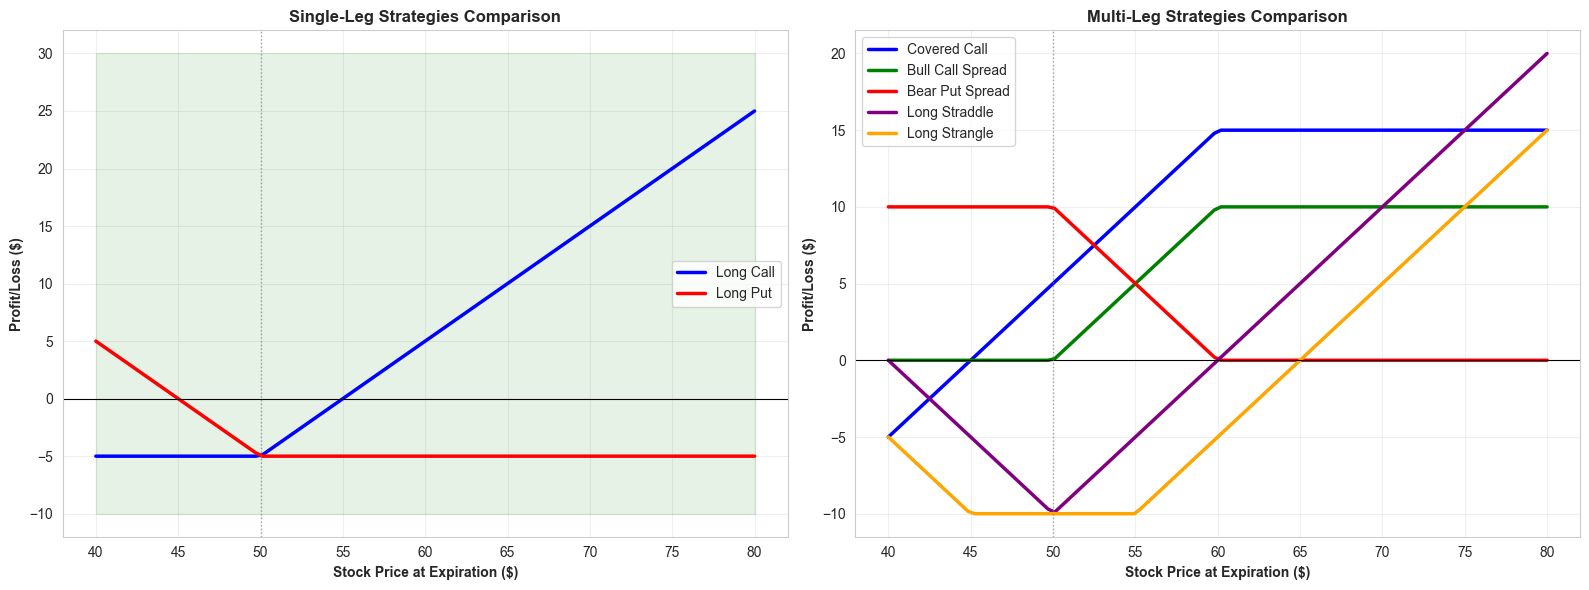

Strategy comparison plots completed!


In [10]:
# Create comparison plots: Single-leg vs Multi-leg strategies
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Single-Leg Strategies Comparison
axes[0].plot(S_range, profit_lc, 'b-', linewidth=2.5, label='Long Call')
axes[0].plot(S_range, profit_lp, 'r-', linewidth=2.5, label='Long Put')
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.8)
axes[0].axvline(x=S0, color='gray', linestyle=':', linewidth=1, alpha=0.7)
axes[0].fill_between(S_range, -10, 30, alpha=0.1, color='green')
axes[0].set_title('Single-Leg Strategies Comparison', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
axes[0].set_ylabel('Profit/Loss ($)', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Multi-Leg Strategies Comparison
axes[1].plot(S_range, profit_cc, 'b-', linewidth=2.5, label='Covered Call')
axes[1].plot(S_range, profit_bc, 'g-', linewidth=2.5, label='Bull Call Spread')
axes[1].plot(S_range, profit_bp, 'r-', linewidth=2.5, label='Bear Put Spread')
axes[1].plot(S_range, profit_st, 'purple', linewidth=2.5, label='Long Straddle')
axes[1].plot(S_range, profit_sr, 'orange', linewidth=2.5, label='Long Strangle')
axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.8)
axes[1].axvline(x=S0, color='gray', linestyle=':', linewidth=1, alpha=0.7)
axes[1].set_title('Multi-Leg Strategies Comparison', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Stock Price at Expiration ($)', fontweight='bold')
axes[1].set_ylabel('Profit/Loss ($)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Strategy comparison plots completed!")

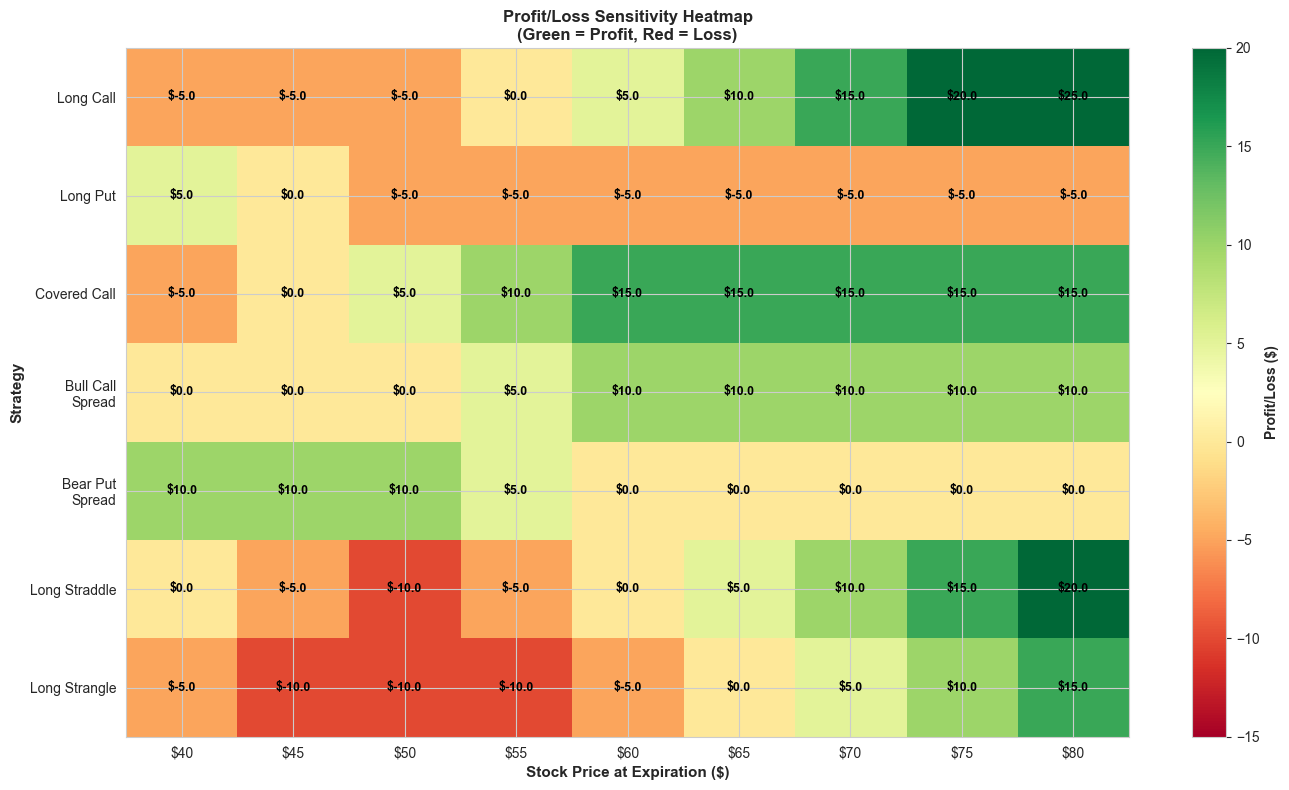

Sensitivity analysis heatmap created!


In [11]:
# Create a sensitivity analysis table showing profit/loss at different stock prices
fig, ax = plt.subplots(figsize=(14, 8))

# Create a matrix of profits for visualization
strategies = ['Long Call', 'Long Put', 'Covered Call', 'Bull Call\nSpread', 'Bear Put\nSpread', 'Long Straddle', 'Long Strangle']
prices = np.array([40, 45, 50, 55, 60, 65, 70, 75, 80])

# Calculate profits at each price
profit_matrix = np.array([
    payoff_long_call(prices, K_long_call, C_premium)[1],
    payoff_long_put(prices, K_long_put, P_premium)[1],
    payoff_covered_call(prices, K_cc_stock, K_cc_call, C_premium)[1],
    payoff_bull_call_spread(prices, K_bc_long, K_bc_short, C_premium, C_premium)[1],
    payoff_bear_put_spread(prices, K_bp_long, K_bp_short, P_premium, P_premium)[1],
    payoff_long_straddle(prices, K_straddle, C_premium, P_premium)[1],
    payoff_long_strangle(prices, K_strangle_put, K_strangle_call, C_premium, P_premium)[1]
])

# Create heatmap
im = ax.imshow(profit_matrix, cmap='RdYlGn', aspect='auto', vmin=-15, vmax=20)

# Set ticks and labels
ax.set_xticks(np.arange(len(prices)))
ax.set_yticks(np.arange(len(strategies)))
ax.set_xticklabels([f'${p}' for p in prices])
ax.set_yticklabels(strategies)
ax.set_xlabel('Stock Price at Expiration ($)', fontweight='bold', fontsize=11)
ax.set_ylabel('Strategy', fontweight='bold', fontsize=11)
ax.set_title('Profit/Loss Sensitivity Heatmap\n(Green = Profit, Red = Loss)', fontweight='bold', fontsize=12)

# Add text annotations
for i in range(len(strategies)):
    for j in range(len(prices)):
        text = ax.text(j, i, f'${profit_matrix[i, j]:.1f}',
                      ha="center", va="center", color="black", fontweight='bold', fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Profit/Loss ($)', fontweight='bold')

plt.tight_layout()
plt.show()

print("Sensitivity analysis heatmap created!")

## Conclusion

### Summary of Findings

This comprehensive analysis of option strategies demonstrates how different combinations of options can be used to achieve specific trading objectives based on market expectations and risk tolerance.

### Key Conclusions

#### 1. **Single-Leg Strategies (Long Call and Long Put)**
   - **Long Call**: Most suitable for bullish outlook with unlimited upside potential. Risk is limited to premium paid ($5).
   - **Long Put**: Ideal for bearish stance with downside protection. Maximum profit is limited but provides capital protection.
   - Both strategies have clear directional bias and simple risk-reward characteristics.

#### 2. **Income-Generating Strategy (Covered Call)**
   - Combines long stock position with short call to generate income
   - Max profit of $15 ($10 appreciation + $5 premium) when stock rises above $60
   - Effective breakeven at $45, reducing downside risk by the premium received
   - Best used in range-bound or mildly bullish markets to generate steady income

#### 3. **Limited Risk Strategies (Bull Call Spread and Bear Put Spread)**
   - **Bull Call Spread**: Reduces capital requirement while limiting both profit ($10 max) and loss ($0)
   - **Bear Put Spread**: Used to sell volatility with defined maximum loss of $10
   - Both strategies are ideal when volatility is expected to be low
   - Offer better risk-reward control compared to naked positions

#### 4. **Volatility Strategies (Long Straddle and Long Strangle)**
   - **Long Straddle**: Symmetric payoff around strike price ($50), benefits from significant price moves in either direction
   - **Long Strangle**: Asymmetric setup with wider breakevens ($35 and $65), lower cost than straddle
   - Both strategies profit from high volatility regardless of price direction
   - Effective when expecting large market moves but uncertain of direction (Earnings announcements, Fed decisions, etc.)

#### 5. **Break-Even Analysis**
   - Each strategy has distinct break-even points that define the price range at which strategy becomes profitable
   - Understanding break-even points is crucial for risk management and pre-trade planning

#### 6. **Risk-Reward Characteristics**
   - Directional strategies (Call/Put) offer unlimited profit potential but concentrated risk
   - Spread strategies limit both risk and reward, suitable for risk-averse investors
   - Volatility strategies benefit from price movement regardless of direction
   - Income strategies (Covered Call) sacrifice unlimited upside for premium income and reduced downside

### Market Conditions and Strategy Selection

| Market Outlook | Volatility | Best Strategy | Rationale |
|----------------|------------|---------------|-----------|
| Strongly Bullish | Low | Long Call | Unlimited profit potential |
| Strongly Bearish | Low | Long Put | Unlimited profit potential |
| Mildly Bullish | Low | Bull Call Spread | Reduced cost, defined risk-reward |
| Mildly Bearish | Low | Bear Put Spread | Income generation with defined risk |
| Range-Bound | Low | Covered Call | Income generation from static position |
| Uncertain | High | Long Straddle | Benefit from volatility spike |
| Uncertain | High | Long Strangle | Low-cost volatility play |

### Practical Implications

1. **Cost Efficiency**: Spreading strategies (bull call spread, bear put spread) reduce upfront capital requirements
2. **Risk Management**: Defined-risk strategies better suit risk-averse investors
3. **Market Timing**: Strategy selection depends on both market outlook AND implied volatility levels
4. **Greeks Impact**: Theta decay works for income strategies but against long options
5. **Position Sizing**: Larger payoff potential requires careful position sizing and risk management

### Limitations and Considerations

- Analysis assumes European-style options (no early exercise)
- Ignores transaction costs and bid-ask spreads
- Does not account for dividends or interest rate changes
- Greeks (Delta, Gamma, Vega, Theta, Rho) vary throughout the holding period
- Real-world volatility and prices may differ significantly from Black-Scholes assumptions

### Future Applications

- Use this framework to evaluate real market opportunities
- Combine strategies based on market conditions and portfolio objectives
- Monitor Greeks to understand real-time risk exposure
- Consider IV crush effects when volatility returns to normal levels
- Backtest strategies on historical data to validate performance

In [12]:
# Create Final Summary Report
print("\n" + "="*100)
print(" "*30 + "FINAL LABORATORY SUMMARY REPORT")
print("="*100)
print(f"\nExperiment: Basic and Advanced Option Strategies with Payoff Profiles")
print(f"Date: March 29, 2026")
print(f"Current Stock Price: ${S0}")
print(f"Option Premium (Call & Put): ${C_premium}")
print(f"Analysis Period: {T*365:.0f} days to expiration")

print("\n" + "-"*100)
print("TASKS COMPLETED:")
print("-"*100)
print("✓ Task 1: Plotted payoff profiles for all 7 strategies")
print("✓ Task 2: Interpreted payoff profiles for different market conditions")
print("✓ Task 3: Calculated profit/loss after accounting for option premiums")
print("✓ Task 4: Identified break-even points for each strategy")
print("✓ Task 5: Compared risk and reward characteristics")
print("✓ Task 6: Created detailed payoff diagrams using Python visualization")

print("\n" + "-"*100)
print("STRATEGIES ANALYZED:")
print("-"*100)

strategy_summary = [
    "1. Long Call      - Directional play on upside, unlimited profit potential",
    "2. Long Put       - Directional play on downside, protective strategy",
    "3. Covered Call   - Income generation with reduced downside risk",
    "4. Bull Call Spd  - Bullish outlook with defined risk-reward",
    "5. Bear Put Spd   - Bearish outlook with defined risk-reward",
    "6. Long Straddle  - Volatility play expecting large moves",
    "7. Long Strangle  - Low-cost volatility play"
]

for strategy in strategy_summary:
    print(f"   {strategy}")

print("\n" + "-"*100)
print("KEY INSIGHTS:")
print("-"*100)
print("""
• Directional strategies (Long Call/Put) suitable for traders with strong market conviction
• Spread strategies offer better risk-reward balance and reduced capital requirements
• Volatility strategies (Straddle/Strangle) benefit from uncertainty and expected large moves
• Income strategies (Covered Call) sacrifice unlimited upside for premium income
• Break-even analysis critical for understanding strategy profitability thresholds
• Risk/Reward ratios vary significantly, affecting capital allocation decisions
""")

print("-"*100)
print("VISUALIZATIONS GENERATED:")
print("-"*100)
print("""
1. 7-Strategy Payoff Profile Grid (Individual plots for all strategies)
2. Single-Leg vs Multi-Leg Strategy Comparison (2-panel comparison)
3. Profit/Loss Sensitivity Heatmap (All strategies across price range)
4. Detailed Break-Even Analysis (Exact breakeven prices for each strategy)
5. Risk-Reward Metrics Comparison (Max profit, loss, and ratios)
6. Comprehensive Profit/Loss Tables (At key price levels)
""")

print("\n" + "="*100)
print("LABORATORY EXERCISE COMPLETE")
print("="*100 + "\n")


                              FINAL LABORATORY SUMMARY REPORT

Experiment: Basic and Advanced Option Strategies with Payoff Profiles
Date: March 29, 2026
Current Stock Price: $50
Option Premium (Call & Put): $5
Analysis Period: 30 days to expiration

----------------------------------------------------------------------------------------------------
TASKS COMPLETED:
----------------------------------------------------------------------------------------------------
✓ Task 1: Plotted payoff profiles for all 7 strategies
✓ Task 2: Interpreted payoff profiles for different market conditions
✓ Task 3: Calculated profit/loss after accounting for option premiums
✓ Task 4: Identified break-even points for each strategy
✓ Task 5: Compared risk and reward characteristics
✓ Task 6: Created detailed payoff diagrams using Python visualization

----------------------------------------------------------------------------------------------------
STRATEGIES ANALYZED:
---------------------------------